### On va essayer de soustraire les cartes temps fréquence pour montrer les différences

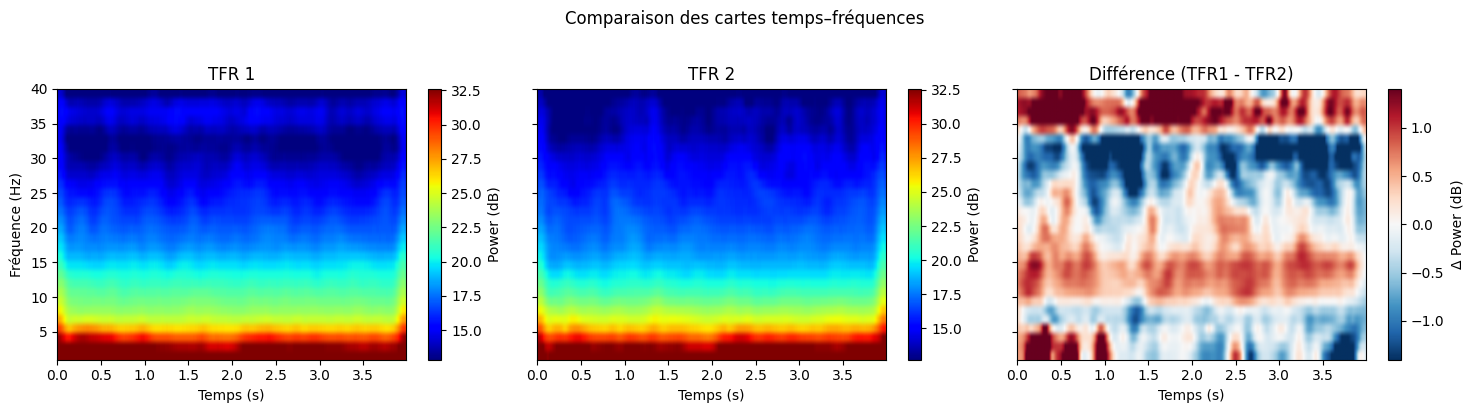

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tf1_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/group_Fp1-C3_power.npy")
tf2_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/group_Fp2-T4_power.npy")
time_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/times.npy")
freq_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/freqs.npy")

# Chargement 
tf1 = np.load(tf1_path)
tf2 = np.load(tf2_path)
time = np.load(time_path)
freq = np.load(freq_path)

# Alignement si dimensions différentes (rognage au min) 
f_len = min(tf1.shape[0], tf2.shape[0], len(freq))
t_len = min(tf1.shape[1], tf2.shape[1], len(time))
tf1_ = tf1[:f_len, :t_len]
tf2_ = tf2[:f_len, :t_len]
freq_ = np.asarray(freq[:f_len])
time_ = np.asarray(time[:t_len])

# Différence absolue (en dB) 
diff = tf1_ - tf2_

# Helpers d'affichage 
def robust_limits(A, p_lo=5, p_hi=95):
    A = A[np.isfinite(A)]
    if A.size == 0:
        return -1.0, 1.0
    lo, hi = np.percentile(A, [p_lo, p_hi])
    if lo == hi:
        eps = 1e-6
        return lo - eps, hi + eps
    return float(lo), float(hi)

def extent_from_axes(time_v, freq_v, Z):
    # Sécurise l'extent par rapport aux tailles affichées
    return [time_v[0], time_v[len(Z[0]) - 1], freq_v[0], freq_v[len(Z) - 1]]

# Échelles couleur
vmin1, vmax1 = robust_limits(tf1_)
vmin2, vmax2 = robust_limits(tf2_)

# Échelle symétrique centrée 0 pour la différence
lo_d, hi_d = robust_limits(diff)
vmax_d = max(abs(lo_d), abs(hi_d)) or 1e-6
vmin_d, vmax_d = -vmax_d, vmax_d

# Plot côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

# TFR 1
im1 = axes[0].imshow(tf1_, aspect='auto', origin='lower',
                     extent=extent_from_axes(time_, freq_, tf1_),
                     cmap='jet', vmin=vmin1, vmax=vmax1)
axes[0].set_title('TFR 1')
axes[0].set_xlabel('Temps (s)')
axes[0].set_ylabel('Fréquence (Hz)')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Power (dB)')

# TFR 2
im2 = axes[1].imshow(tf2_, aspect='auto', origin='lower',
                     extent=extent_from_axes(time_, freq_, tf2_),
                     cmap='jet', vmin=vmin2, vmax=vmax2)
axes[1].set_title('TFR 2')
axes[1].set_xlabel('Temps (s)')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Power (dB)')

# Différence (TFR1 - TFR2)
im3 = axes[2].imshow(diff, aspect='auto', origin='lower',
                     extent=extent_from_axes(time_, freq_, diff),
                     cmap='RdBu_r', vmin=vmin_d, vmax=vmax_d)
axes[2].set_title('Différence (TFR1 - TFR2)')
axes[2].set_xlabel('Temps (s)')
cbar3 = plt.colorbar(im3, ax=axes[2])
cbar3.set_label('Delta Power (dB)')

fig.suptitle('Comparaison des cartes temps-fréquences', y=1.02, fontsize=12)
fig.tight_layout()
plt.show()
 
# fig.savefig('tfr_compare_and_diff.png', dpi=300, bbox_inches='tight')


[INFO] Catégorie: narco | Stage: REM | Canal: Fp1-A1
  - stack shape = (11, 30, 400)  (n_sujets, n_freqs, n_times)
  - group shape = (30, 400)  (n_freqs, n_times)
  - times.shape = (400,)  | freqs.shape = (30,)


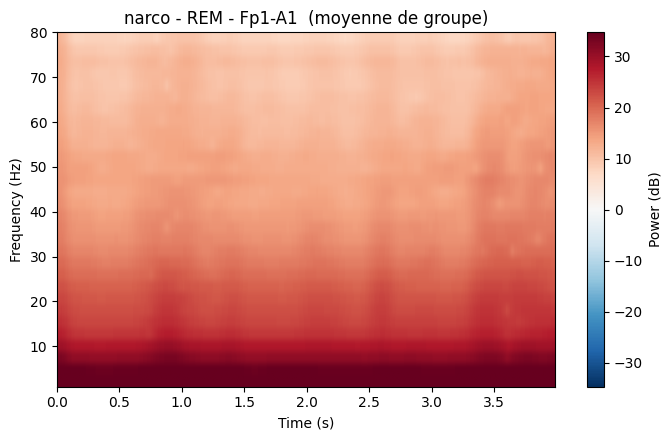

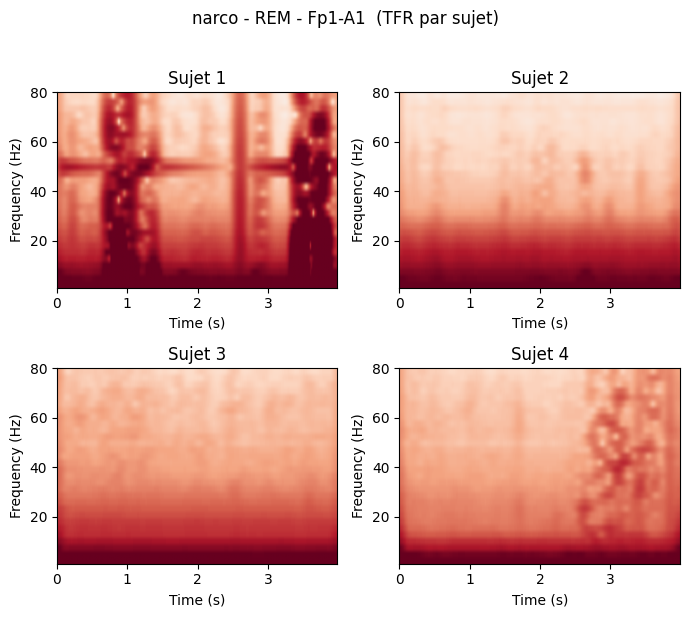

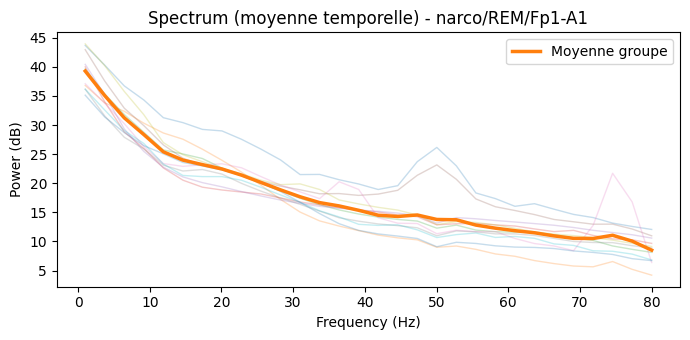

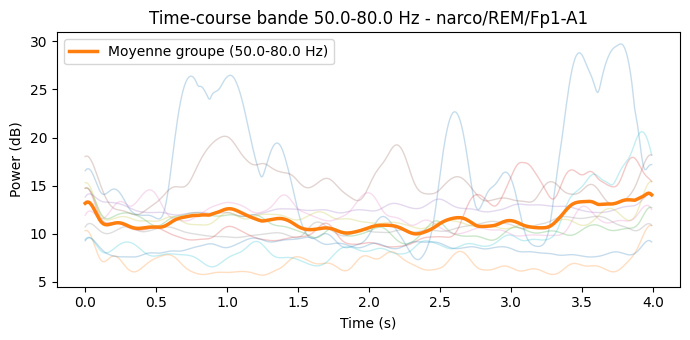

In [10]:
# Analyse des fichiers .npy

# %% Visualisation rapide des fichiers .npy (stack_* et group_*_power)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ========== PARAMS À ADAPTER ==========
# Racine: .../_by_patient_category/{categorie}/{stage}/
ROOT = Path("/home/darryld/documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category")
categorie = "narco"       # ex: "syn", "narco", etc.
stage     = "REM"       # "REM", "N2", "N3"
channel   = "Fp1-A1"    # nom exact tel qu'enregistré (sans sanitize manuel)

# Bande pour time-course (moyenne freq -> temps)
band = (50.0, 80.0)      
# ======================================

D = ROOT / categorie / stage
times = np.load(D / "times.npy")
freqs = np.load(D / "freqs.npy")

stack_path = D / f"stack_{channel}.npy"
group_path = D / f"group_{channel}_power.npy"

if not stack_path.exists() or not group_path.exists():
    raise FileNotFoundError(f"Fichiers manquants pour {channel} dans {D}")

stack = np.load(stack_path)     # (n_sujets, F, T)
group = np.load(group_path)     # (F, T)

# Par sécurité: rogne times/freqs si besoin
F, T = group.shape
times = times[:T]
freqs = freqs[:F]

n_subj = stack.shape[0]
print(f"[INFO] Catégorie: {categorie} | Stage: {stage} | Canal: {channel}")
print(f"  - stack shape = {stack.shape}  (n_sujets, n_freqs, n_times)")
print(f"  - group shape = {group.shape}  (n_freqs, n_times)")
print(f"  - times.shape = {times.shape}  | freqs.shape = {freqs.shape}")
assert stack.shape[1:] == group.shape, "Incohérence de dimensions F×T entre stack et group."

# Petit helper: limite couleur symétrique robuste
def robust_sym_limits(A, lo=5, hi=95):
    A = A[np.isfinite(A)]
    if A.size == 0:
        return (-1.0, 1.0)
    p = np.percentile(A, [lo, hi])
    m = max(abs(p[0]), abs(p[1]))
    return (-m if m > 0 else -1e-6, m if m > 0 else 1e-6)

# ---------- 1) Carte TFR moyenne (group) ----------
vmin, vmax = robust_sym_limits(group)
plt.figure(figsize=(7, 4.5))
plt.imshow(group, aspect="auto", origin="lower",
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title(f"{categorie} - {stage} - {channel}  (moyenne de groupe)")
plt.tight_layout()
plt.show()

# ---------- 2) TFR de quelques sujets ----------
k = min(4, n_subj)  # jusqu'à 4 sujets affichés
rows = 1 if k <= 3 else 2
cols = k if k <= 3 else 2
fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.0*rows), squeeze=False)
for i in range(k):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    vmin_s, vmax_s = robust_sym_limits(stack[i])
    ax.imshow(stack[i], aspect="auto", origin="lower",
              extent=[times[0], times[-1], freqs[0], freqs[-1]],
              cmap="RdBu_r", vmin=vmin, vmax=vmax)  # même échelle que la moyenne pour comparaison
    ax.set_title(f"Sujet {i+1}")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Frequency (Hz)")
# Cache axes vides si k<rows*cols
for j in range(k, rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")
fig.suptitle(f"{categorie} - {stage} - {channel}  (TFR par sujet)", y=1.02)
fig.tight_layout()
plt.show()

# ---------- 3) Spectre: moyenne temporelle ----------
group_spec = group.mean(axis=1)  # (F,)
plt.figure(figsize=(7, 3.5))
for i in range(n_subj):
    plt.plot(freqs, stack[i].mean(axis=1), alpha=0.25, linewidth=1)
plt.plot(freqs, group_spec, linewidth=2.5, label="Moyenne groupe")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Power (dB)")
plt.title(f"Spectrum (moyenne temporelle) - {categorie}/{stage}/{channel}")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 4) Time-course d'une bande fréquentielle ----------
fmin, fmax = band
band_mask = (freqs >= fmin) & (freqs <= fmax)
if band_mask.any():
    group_tc = group[band_mask].mean(axis=0)  # (T,)
    plt.figure(figsize=(7, 3.5))
    for i in range(n_subj):
        plt.plot(times, stack[i][band_mask].mean(axis=0), alpha=0.25, linewidth=1)
    plt.plot(times, group_tc, linewidth=2.5, label=f"Moyenne groupe ({fmin}-{fmax} Hz)")
    plt.xlabel("Time (s)"); plt.ylabel("Power (dB)")
    plt.title(f"Time-course bande {fmin}-{fmax} Hz - {categorie}/{stage}/{channel}")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] Bande {band} Hz hors des fréquences disponibles [{freqs[0]}, {freqs[-1]}].")


[INFO] Catégorie: syn | Stage: REM | Canal: Fp1-A1
  - stack shape = (18, 30, 400)  (n_sujets, n_freqs, n_times)
  - group shape = (30, 400)  (n_freqs, n_times)
  - times.shape = (400,)  | freqs.shape = (30,)


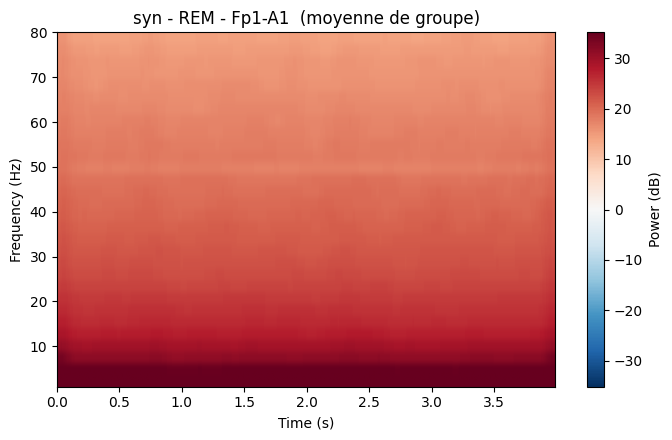

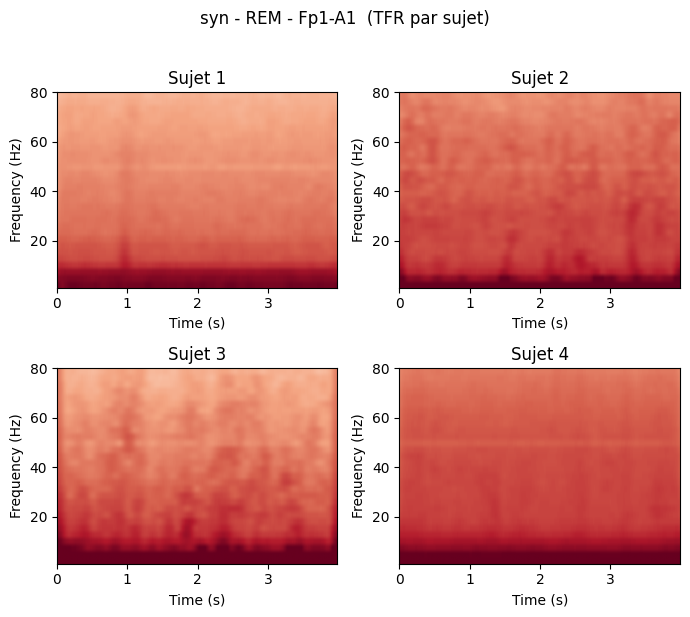

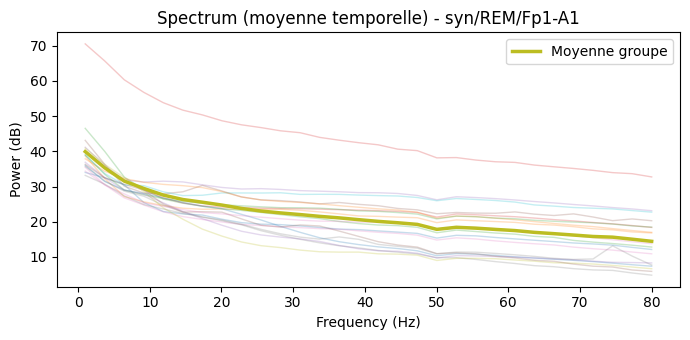

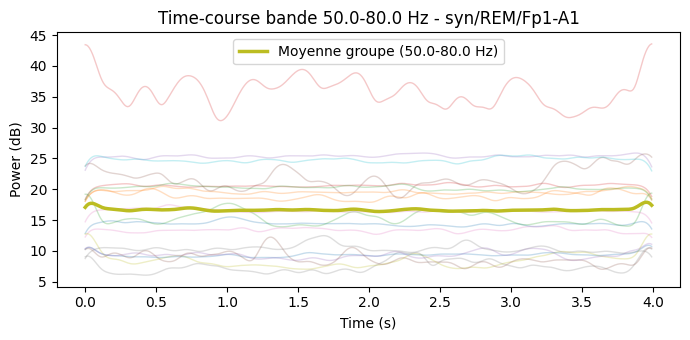

In [11]:
# Analyse des fichiers .npy

# %% Visualisation rapide des fichiers .npy (stack_* et group_*_power)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ========== PARAMS À ADAPTER ==========
# Racine: .../_by_patient_category/{categorie}/{stage}/
ROOT = Path("/home/darryld/documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category")
categorie = "syn"       # ex: "syn", "narco", etc.
stage     = "REM"       # "REM", "N2", "N3"
channel   = "Fp1-A1"    # nom exact tel qu'enregistré (sans sanitize manuel)

# Bande pour time-course (moyenne freq -> temps)
band = (50.0, 80.0)      
# ======================================

D = ROOT / categorie / stage
times = np.load(D / "times.npy")
freqs = np.load(D / "freqs.npy")

stack_path = D / f"stack_{channel}.npy"
group_path = D / f"group_{channel}_power.npy"

if not stack_path.exists() or not group_path.exists():
    raise FileNotFoundError(f"Fichiers manquants pour {channel} dans {D}")

stack = np.load(stack_path)     # (n_sujets, F, T)
group = np.load(group_path)     # (F, T)

# Par sécurité: rogne times/freqs si besoin
F, T = group.shape
times = times[:T]
freqs = freqs[:F]

n_subj = stack.shape[0]
print(f"[INFO] Catégorie: {categorie} | Stage: {stage} | Canal: {channel}")
print(f"  - stack shape = {stack.shape}  (n_sujets, n_freqs, n_times)")
print(f"  - group shape = {group.shape}  (n_freqs, n_times)")
print(f"  - times.shape = {times.shape}  | freqs.shape = {freqs.shape}")
assert stack.shape[1:] == group.shape, "Incohérence de dimensions F×T entre stack et group."

# Petit helper: limite couleur symétrique robuste
def robust_sym_limits(A, lo=5, hi=95):
    A = A[np.isfinite(A)]
    if A.size == 0:
        return (-1.0, 1.0)
    p = np.percentile(A, [lo, hi])
    m = max(abs(p[0]), abs(p[1]))
    return (-m if m > 0 else -1e-6, m if m > 0 else 1e-6)

# ---------- 1) Carte TFR moyenne (group) ----------
vmin, vmax = robust_sym_limits(group)
plt.figure(figsize=(7, 4.5))
plt.imshow(group, aspect="auto", origin="lower",
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title(f"{categorie} - {stage} - {channel}  (moyenne de groupe)")
plt.tight_layout()
plt.show()

# ---------- 2) TFR de quelques sujets ----------
k = min(4, n_subj)  # jusqu'à 4 sujets affichés
rows = 1 if k <= 3 else 2
cols = k if k <= 3 else 2
fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.0*rows), squeeze=False)
for i in range(k):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    vmin_s, vmax_s = robust_sym_limits(stack[i])
    ax.imshow(stack[i], aspect="auto", origin="lower",
              extent=[times[0], times[-1], freqs[0], freqs[-1]],
              cmap="RdBu_r", vmin=vmin, vmax=vmax)  # même échelle que la moyenne pour comparaison
    ax.set_title(f"Sujet {i+1}")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Frequency (Hz)")
# Cache axes vides si k<rows*cols
for j in range(k, rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")
fig.suptitle(f"{categorie} - {stage} - {channel}  (TFR par sujet)", y=1.02)
fig.tight_layout()
plt.show()

# ---------- 3) Spectre: moyenne temporelle ----------
group_spec = group.mean(axis=1)  # (F,)
plt.figure(figsize=(7, 3.5))
for i in range(n_subj):
    plt.plot(freqs, stack[i].mean(axis=1), alpha=0.25, linewidth=1)
plt.plot(freqs, group_spec, linewidth=2.5, label="Moyenne groupe")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Power (dB)")
plt.title(f"Spectrum (moyenne temporelle) - {categorie}/{stage}/{channel}")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 4) Time-course d'une bande fréquentielle ----------
fmin, fmax = band
band_mask = (freqs >= fmin) & (freqs <= fmax)
if band_mask.any():
    group_tc = group[band_mask].mean(axis=0)  # (T,)
    plt.figure(figsize=(7, 3.5))
    for i in range(n_subj):
        plt.plot(times, stack[i][band_mask].mean(axis=0), alpha=0.25, linewidth=1)
    plt.plot(times, group_tc, linewidth=2.5, label=f"Moyenne groupe ({fmin}-{fmax} Hz)")
    plt.xlabel("Time (s)"); plt.ylabel("Power (dB)")
    plt.title(f"Time-course bande {fmin}-{fmax} Hz - {categorie}/{stage}/{channel}")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] Bande {band} Hz hors des fréquences disponibles [{freqs[0]}, {freqs[-1]}].")


[INFO] Catégorie: eai | Stage: REM | Canal: Fp1-A1
  - stack shape = (7, 30, 400)  (n_sujets, n_freqs, n_times)
  - group shape = (30, 400)  (n_freqs, n_times)
  - times.shape = (400,)  | freqs.shape = (30,)


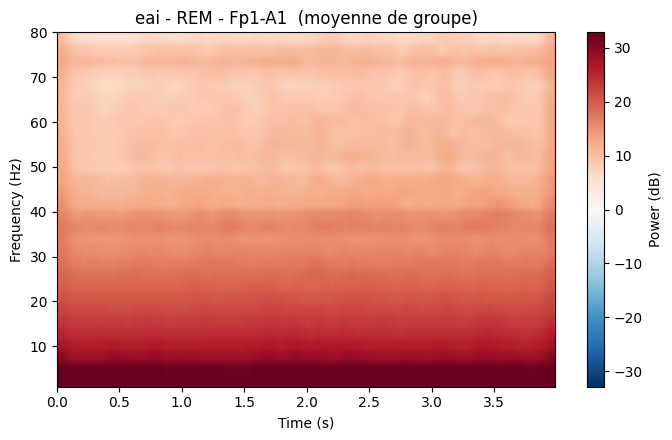

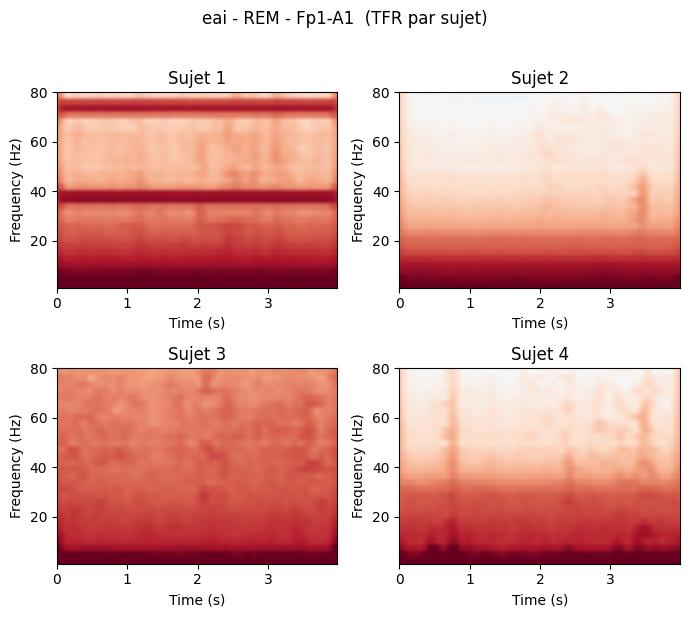

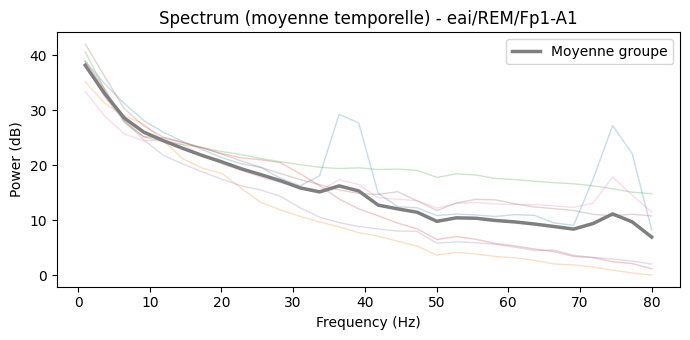

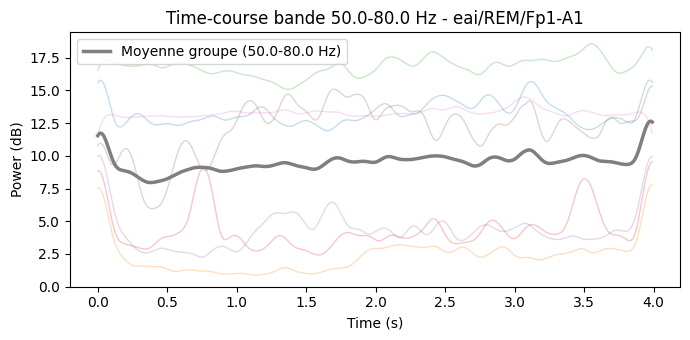

In [12]:
# Analyse des fichiers .npy

# %% Visualisation rapide des fichiers .npy (stack_* et group_*_power)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ========== PARAMS À ADAPTER ==========
# Racine: .../_by_patient_category/{categorie}/{stage}/
ROOT = Path("/home/darryld/documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category")
categorie = "eai"       # ex: "syn", "narco", etc.
stage     = "REM"       # "REM", "N2", "N3"
channel   = "Fp1-A1"    # nom exact tel qu'enregistré (sans sanitize manuel)

# Bande pour time-course (moyenne freq -> temps)
band = (50.0, 80.0)      
# ======================================

D = ROOT / categorie / stage
times = np.load(D / "times.npy")
freqs = np.load(D / "freqs.npy")

stack_path = D / f"stack_{channel}.npy"
group_path = D / f"group_{channel}_power.npy"

if not stack_path.exists() or not group_path.exists():
    raise FileNotFoundError(f"Fichiers manquants pour {channel} dans {D}")

stack = np.load(stack_path)     # (n_sujets, F, T)
group = np.load(group_path)     # (F, T)

# Par sécurité: rogne times/freqs si besoin
F, T = group.shape
times = times[:T]
freqs = freqs[:F]

n_subj = stack.shape[0]
print(f"[INFO] Catégorie: {categorie} | Stage: {stage} | Canal: {channel}")
print(f"  - stack shape = {stack.shape}  (n_sujets, n_freqs, n_times)")
print(f"  - group shape = {group.shape}  (n_freqs, n_times)")
print(f"  - times.shape = {times.shape}  | freqs.shape = {freqs.shape}")
assert stack.shape[1:] == group.shape, "Incohérence de dimensions F×T entre stack et group."

# Petit helper: limite couleur symétrique robuste
def robust_sym_limits(A, lo=5, hi=95):
    A = A[np.isfinite(A)]
    if A.size == 0:
        return (-1.0, 1.0)
    p = np.percentile(A, [lo, hi])
    m = max(abs(p[0]), abs(p[1]))
    return (-m if m > 0 else -1e-6, m if m > 0 else 1e-6)

# ---------- 1) Carte TFR moyenne (group) ----------
vmin, vmax = robust_sym_limits(group)
plt.figure(figsize=(7, 4.5))
plt.imshow(group, aspect="auto", origin="lower",
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title(f"{categorie} - {stage} - {channel}  (moyenne de groupe)")
plt.tight_layout()
plt.show()

# ---------- 2) TFR de quelques sujets ----------
k = min(4, n_subj)  # jusqu'à 4 sujets affichés
rows = 1 if k <= 3 else 2
cols = k if k <= 3 else 2
fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.0*rows), squeeze=False)
for i in range(k):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    vmin_s, vmax_s = robust_sym_limits(stack[i])
    ax.imshow(stack[i], aspect="auto", origin="lower",
              extent=[times[0], times[-1], freqs[0], freqs[-1]],
              cmap="RdBu_r", vmin=vmin, vmax=vmax)  # même échelle que la moyenne pour comparaison
    ax.set_title(f"Sujet {i+1}")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Frequency (Hz)")
# Cache axes vides si k<rows*cols
for j in range(k, rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")
fig.suptitle(f"{categorie} - {stage} - {channel}  (TFR par sujet)", y=1.02)
fig.tight_layout()
plt.show()

# ---------- 3) Spectre: moyenne temporelle ----------
group_spec = group.mean(axis=1)  # (F,)
plt.figure(figsize=(7, 3.5))
for i in range(n_subj):
    plt.plot(freqs, stack[i].mean(axis=1), alpha=0.25, linewidth=1)
plt.plot(freqs, group_spec, linewidth=2.5, label="Moyenne groupe")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Power (dB)")
plt.title(f"Spectrum (moyenne temporelle) - {categorie}/{stage}/{channel}")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 4) Time-course d'une bande fréquentielle ----------
fmin, fmax = band
band_mask = (freqs >= fmin) & (freqs <= fmax)
if band_mask.any():
    group_tc = group[band_mask].mean(axis=0)  # (T,)
    plt.figure(figsize=(7, 3.5))
    for i in range(n_subj):
        plt.plot(times, stack[i][band_mask].mean(axis=0), alpha=0.25, linewidth=1)
    plt.plot(times, group_tc, linewidth=2.5, label=f"Moyenne groupe ({fmin}-{fmax} Hz)")
    plt.xlabel("Time (s)"); plt.ylabel("Power (dB)")
    plt.title(f"Time-course bande {fmin}-{fmax} Hz - {categorie}/{stage}/{channel}")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] Bande {band} Hz hors des fréquences disponibles [{freqs[0]}, {freqs[-1]}].")


[INFO] Catégorie: tcspi | Stage: REM | Canal: Fp1-A1
  - stack shape = (38, 30, 400)  (n_sujets, n_freqs, n_times)
  - group shape = (30, 400)  (n_freqs, n_times)
  - times.shape = (400,)  | freqs.shape = (30,)


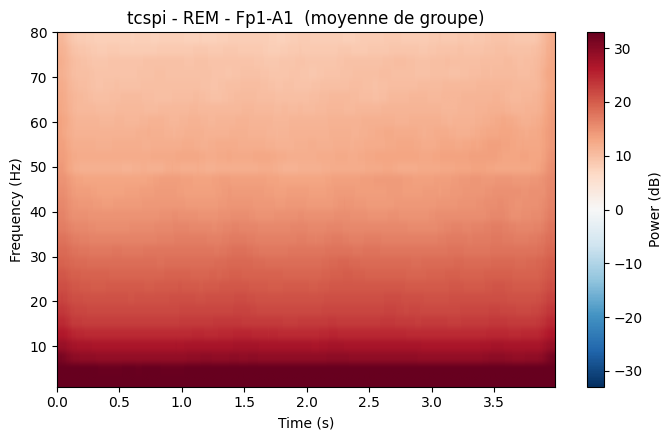

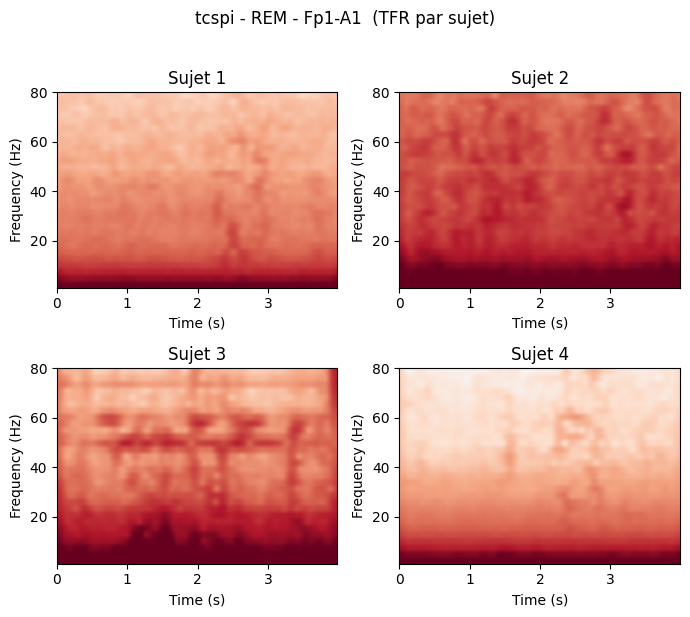

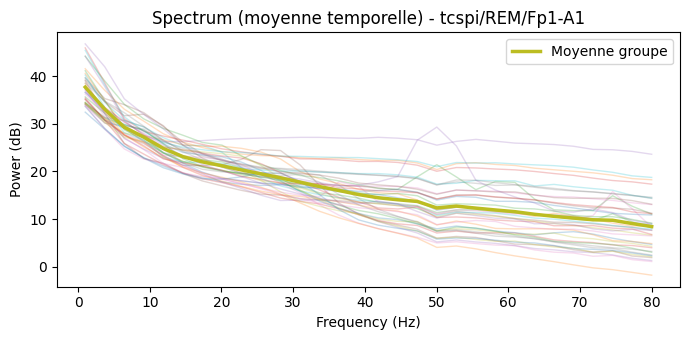

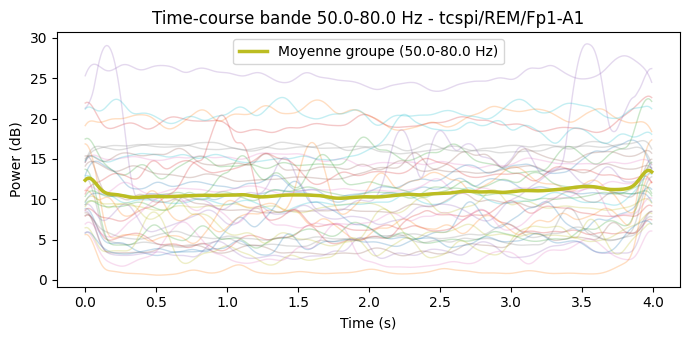

In [13]:
# Analyse des fichiers .npy

# %% Visualisation rapide des fichiers .npy (stack_* et group_*_power)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ========== PARAMS À ADAPTER ==========
# Racine: .../_by_patient_category/{categorie}/{stage}/
ROOT = Path("/home/darryld/documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category")
categorie = "tcspi"       # ex: "syn", "narco", etc.
stage     = "REM"       # "REM", "N2", "N3"
channel   = "Fp1-A1"    # nom exact tel qu'enregistré (sans sanitize manuel)

# Bande pour time-course (moyenne freq -> temps)
band = (50.0, 80.0)      
# ======================================

D = ROOT / categorie / stage
times = np.load(D / "times.npy")
freqs = np.load(D / "freqs.npy")

stack_path = D / f"stack_{channel}.npy"
group_path = D / f"group_{channel}_power.npy"

if not stack_path.exists() or not group_path.exists():
    raise FileNotFoundError(f"Fichiers manquants pour {channel} dans {D}")

stack = np.load(stack_path)     # (n_sujets, F, T)
group = np.load(group_path)     # (F, T)

# Par sécurité: rogne times/freqs si besoin
F, T = group.shape
times = times[:T]
freqs = freqs[:F]

n_subj = stack.shape[0]
print(f"[INFO] Catégorie: {categorie} | Stage: {stage} | Canal: {channel}")
print(f"  - stack shape = {stack.shape}  (n_sujets, n_freqs, n_times)")
print(f"  - group shape = {group.shape}  (n_freqs, n_times)")
print(f"  - times.shape = {times.shape}  | freqs.shape = {freqs.shape}")
assert stack.shape[1:] == group.shape, "Incohérence de dimensions F×T entre stack et group."

# Petit helper: limite couleur symétrique robuste
def robust_sym_limits(A, lo=5, hi=95):
    A = A[np.isfinite(A)]
    if A.size == 0:
        return (-1.0, 1.0)
    p = np.percentile(A, [lo, hi])
    m = max(abs(p[0]), abs(p[1]))
    return (-m if m > 0 else -1e-6, m if m > 0 else 1e-6)

# ---------- 1) Carte TFR moyenne (group) ----------
vmin, vmax = robust_sym_limits(group)
plt.figure(figsize=(7, 4.5))
plt.imshow(group, aspect="auto", origin="lower",
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title(f"{categorie} - {stage} - {channel}  (moyenne de groupe)")
plt.tight_layout()
plt.show()

# ---------- 2) TFR de quelques sujets ----------
k = min(4, n_subj)  # jusqu'à 4 sujets affichés
rows = 1 if k <= 3 else 2
cols = k if k <= 3 else 2
fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.0*rows), squeeze=False)
for i in range(k):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    vmin_s, vmax_s = robust_sym_limits(stack[i])
    ax.imshow(stack[i], aspect="auto", origin="lower",
              extent=[times[0], times[-1], freqs[0], freqs[-1]],
              cmap="RdBu_r", vmin=vmin, vmax=vmax)  # même échelle que la moyenne pour comparaison
    ax.set_title(f"Sujet {i+1}")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Frequency (Hz)")
# Cache axes vides si k<rows*cols
for j in range(k, rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")
fig.suptitle(f"{categorie} - {stage} - {channel}  (TFR par sujet)", y=1.02)
fig.tight_layout()
plt.show()

# ---------- 3) Spectre: moyenne temporelle ----------
group_spec = group.mean(axis=1)  # (F,)
plt.figure(figsize=(7, 3.5))
for i in range(n_subj):
    plt.plot(freqs, stack[i].mean(axis=1), alpha=0.25, linewidth=1)
plt.plot(freqs, group_spec, linewidth=2.5, label="Moyenne groupe")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Power (dB)")
plt.title(f"Spectrum (moyenne temporelle) - {categorie}/{stage}/{channel}")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 4) Time-course d'une bande fréquentielle ----------
fmin, fmax = band
band_mask = (freqs >= fmin) & (freqs <= fmax)
if band_mask.any():
    group_tc = group[band_mask].mean(axis=0)  # (T,)
    plt.figure(figsize=(7, 3.5))
    for i in range(n_subj):
        plt.plot(times, stack[i][band_mask].mean(axis=0), alpha=0.25, linewidth=1)
    plt.plot(times, group_tc, linewidth=2.5, label=f"Moyenne groupe ({fmin}-{fmax} Hz)")
    plt.xlabel("Time (s)"); plt.ylabel("Power (dB)")
    plt.title(f"Time-course bande {fmin}-{fmax} Hz - {categorie}/{stage}/{channel}")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] Bande {band} Hz hors des fréquences disponibles [{freqs[0]}, {freqs[-1]}].")
